First Five Rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

Dataset Info:
<class 'pandas.core.fram

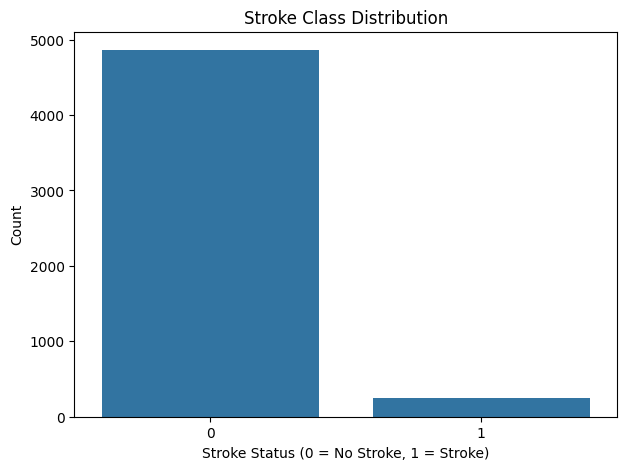

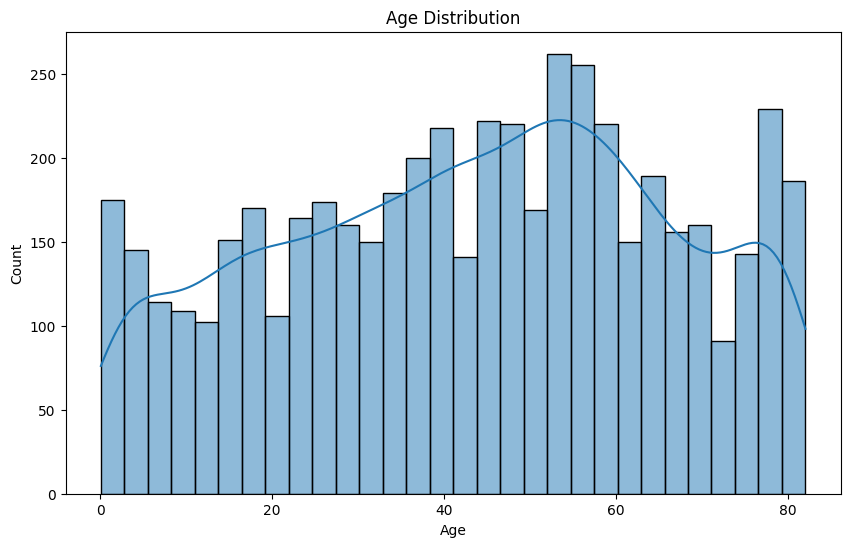

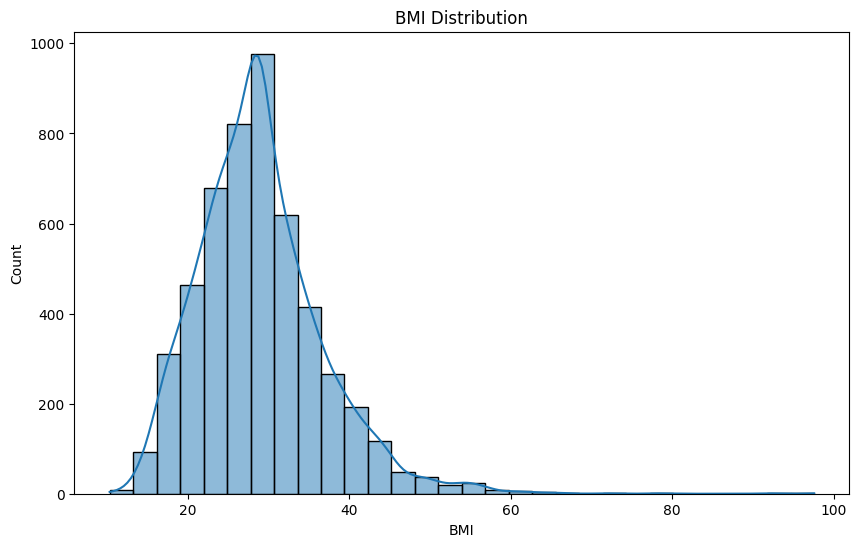

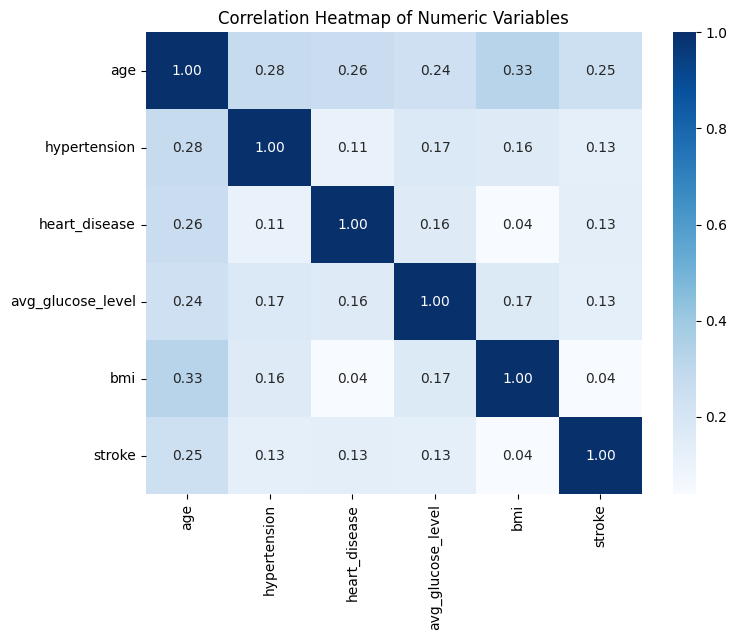


Encoded Dataset Preview:
      id  age  hypertension  heart_disease  avg_glucose_level  bmi  stroke  \
0   9046   67             0              1                228   36       1   
1  51676   61             0              0                202   28       1   
2  31112   80             0              1                105   32       1   
3  60182   49             0              0                171   34       1   
4   1665   79             1              0                174   24       1   

   gender_Male  gender_Other  ever_married_Yes  work_type_Never_worked  \
0            1             0                 1                       0   
1            0             0                 1                       0   
2            1             0                 1                       0   
3            0             0                 1                       0   
4            0             0                 1                       0   

   work_type_Private  work_type_Self-employed  work_type_chi

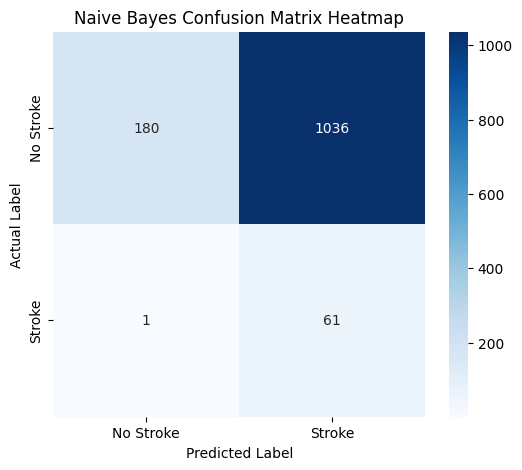


Accuracy Score:
0.18857589984350548

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.15      0.26      1216
           1       0.06      0.98      0.11        62

    accuracy                           0.19      1278
   macro avg       0.53      0.57      0.18      1278
weighted avg       0.95      0.19      0.25      1278


ROC-AUC Score:
0.7956945033955857


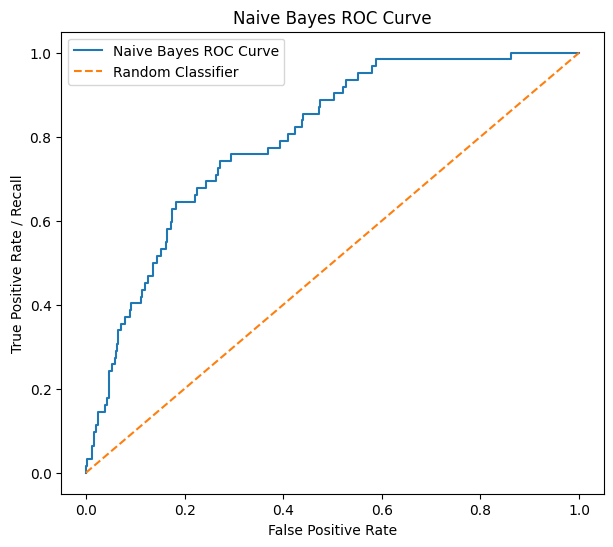


Naive Bayes Class Conditional Means:
                      age  hypertension  heart_disease  avg_glucose_level  \
No Stroke Mean  42.052126      0.088340       0.046365         104.062551   
Stroke Mean     67.636364      0.251337       0.187166         131.245989   

                      bmi  gender_Male  gender_Other  ever_married_Yes  \
No Stroke Mean  28.370096     0.414266      0.000274          0.648560   
Stroke Mean     29.491979     0.422460      0.000000          0.893048   

                work_type_Never_worked  work_type_Private  \
No Stroke Mean                0.003567           0.568176   
Stroke Mean                   0.000000           0.577540   

                work_type_Self-employed  work_type_children  \
No Stroke Mean                 0.159396            0.141564   
Stroke Mean                    0.272727            0.005348   

                Residence_type_Urban  smoking_status_formerly smoked  \
No Stroke Mean              0.504801                        0

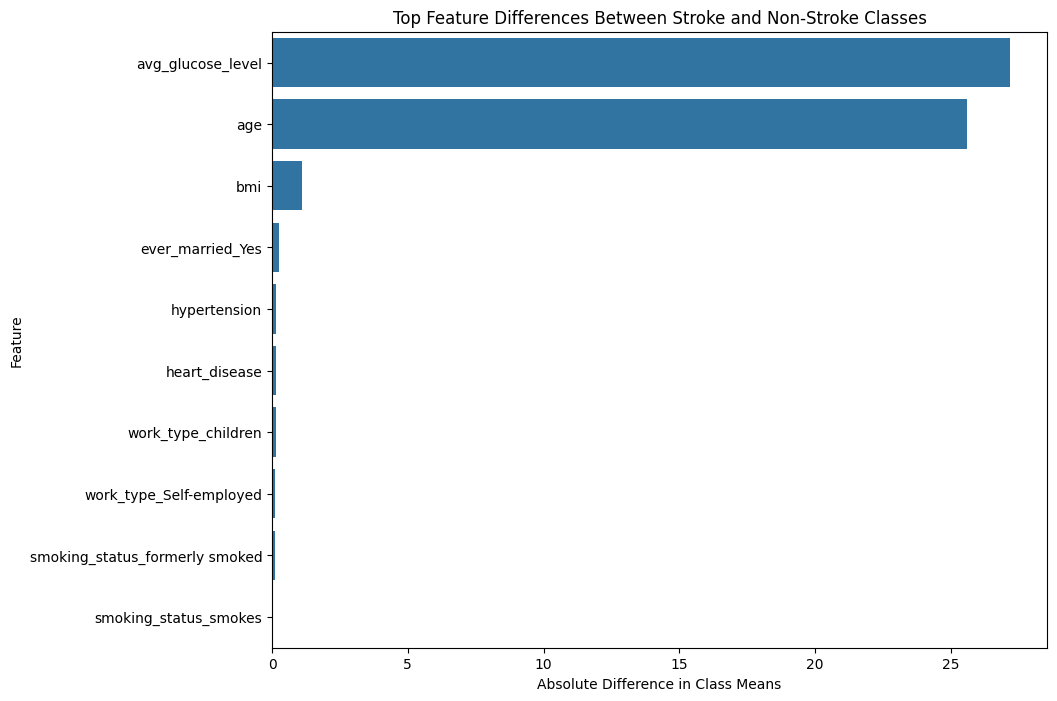

In [2]:
# DATA 430 Assignment 2: Bayesian Classification / Naive Bayes
# Stroke Prediction Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Load dataset
data = pd.read_csv('healthcare_dataset_stroke_data.csv')

# Display first rows
print("First Five Rows:")
print(data.head())

# Dataset structure
print("\nDataset Info:")
print(data.info())

# Missing values before cleaning
print("\nMissing Values Before Cleaning:")
print(data.isnull().sum())

# Replace missing BMI values with the mean BMI
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

# Missing values after cleaning
print("\nMissing Values After Cleaning:")
print(data.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(data.describe())

# ----------------------------
# Exploratory Data Analysis
# ----------------------------

# Figure 1: Stroke Class Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x='stroke')
plt.title('Stroke Class Distribution')
plt.xlabel('Stroke Status (0 = No Stroke, 1 = Stroke)')
plt.ylabel('Count')
plt.show()

# Figure 2: Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Figure 3: BMI Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], bins=30, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

# Figure 4: Correlation Heatmap for Numeric Variables
plt.figure(figsize=(8, 6))
numeric_data = data[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']]
sns.heatmap(numeric_data.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

# ----------------------------
# Preprocessing
# ----------------------------

# Encode categorical variables using one-hot encoding
data_encoded = pd.get_dummies(
    data,
    columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'],
    drop_first=True
)

# Convert Boolean dummy variables to integers
data_encoded = data_encoded.astype(int)

# Define independent and dependent variables
X = data_encoded.drop(columns=['id', 'stroke'])
y = data_encoded['stroke']

print("\nEncoded Dataset Preview:")
print(data_encoded.head())

print("\nIndependent Variables:")
print(X.columns)

print("\nDependent Variable:")
print("stroke")

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ----------------------------
# Parameter tuning: var_smoothing
# ----------------------------

var_smoothing_values = np.logspace(-12, -6, 7)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuning_results = []

for value in var_smoothing_values:
    nb_model = GaussianNB(var_smoothing=value, priors=[0.5, 0.5])
    recall_scores = cross_val_score(
        nb_model,
        X_train,
        y_train,
        cv=cv,
        scoring='recall'
    )
    tuning_results.append({
        'var_smoothing': value,
        'mean_recall': recall_scores.mean()
    })

tuning_results_df = pd.DataFrame(tuning_results)

print("\nNaive Bayes Parameter Tuning Results:")
print(tuning_results_df)

best_var_smoothing = tuning_results_df.sort_values(
    by='mean_recall',
    ascending=False
).iloc[0]['var_smoothing']

print("\nBest var_smoothing value based on recall:")
print(best_var_smoothing)

# ----------------------------
# Model fitting
# ----------------------------

# Create final Gaussian Naive Bayes model
model = GaussianNB(
    var_smoothing=best_var_smoothing,
    priors=[0.5, 0.5]
)

# Fit model
model.fit(X_train, y_train)

# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities for ROC/AUC
y_proba = model.predict_proba(X_test)[:, 1]

# ----------------------------
# Evaluation
# ----------------------------

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Figure 5: Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Stroke', 'Stroke'],
    yticklabels=['No Stroke', 'Stroke']
)
plt.title('Naive Bayes Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy Score:")
print(accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
auc_score = roc_auc_score(y_test, y_proba)
print("\nROC-AUC Score:")
print(auc_score)

# Figure 6: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label='Naive Bayes ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.title('Naive Bayes ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.legend()
plt.show()

# ----------------------------
# Model properties: class conditional means
# ----------------------------

class_means = pd.DataFrame(
    model.theta_,
    columns=X.columns,
    index=['No Stroke Mean', 'Stroke Mean']
)

mean_difference = pd.DataFrame({
    'Feature': X.columns,
    'No_Stroke_Mean': model.theta_[0],
    'Stroke_Mean': model.theta_[1],
    'Absolute_Mean_Difference': abs(model.theta_[1] - model.theta_[0])
})

mean_difference = mean_difference.sort_values(
    by='Absolute_Mean_Difference',
    ascending=False
)

print("\nNaive Bayes Class Conditional Means:")
print(class_means)

print("\nTop Feature Differences Between Stroke and Non-Stroke Classes:")
print(mean_difference)

# Figure 7: Top Feature Differences
plt.figure(figsize=(10, 8))
sns.barplot(
    data=mean_difference.head(10),
    x='Absolute_Mean_Difference',
    y='Feature'
)
plt.title('Top Feature Differences Between Stroke and Non-Stroke Classes')
plt.xlabel('Absolute Difference in Class Means')
plt.ylabel('Feature')
plt.show()